In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.datasets import load_iris

In [42]:
df = load_iris()
df = pd.DataFrame(data=df.data, columns=df.feature_names)
df_labelled = df.copy()
df_labelled['target'] = load_iris().target


In [22]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [23]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [25]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [26]:
df.duplicated().sum()

1

In [27]:
df_1 = df.copy()

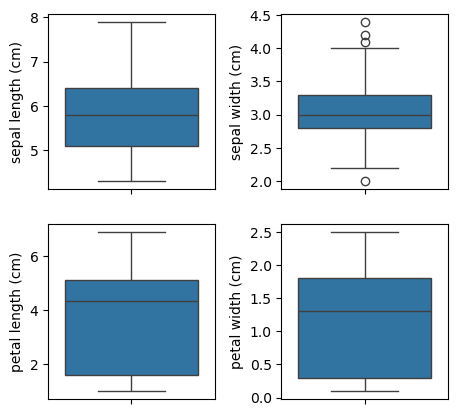

In [29]:

#Using Box plot
plt.subplots(nrows=2 , ncols=2 , figsize=(5,5))
plt.subplots_adjust(left=0.1, right=0.9,wspace=0.4)

for i in range (len(df_1.columns)):

    plt.subplot(2,2,i+1)
    sns.boxplot(df_1[df_1.columns[i]])
plt.show()

<Axes: >

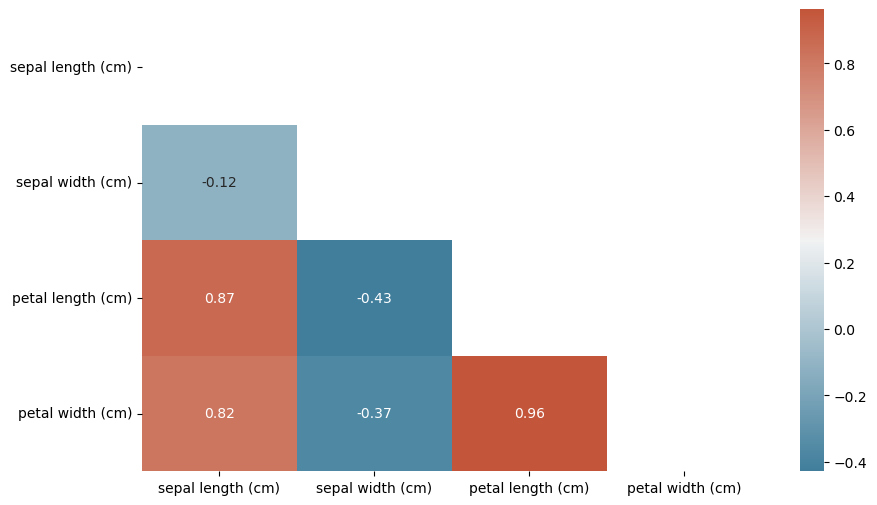

In [30]:
corr = df.corr()

f, ax = plt.subplots(figsize=(10, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, annot=True, mask = mask, cmap=cmap)

In [33]:
df_2 = df.drop(columns ='petal width (cm)')
df_2.head()

,sepal length (cm),sepal width (cm),petal length (cm)
0,5.1,3.5,1.4
1,4.9,3.0,1.4
2,4.7,3.2,1.3
3,4.6,3.1,1.5
4,5.0,3.6,1.4


In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [61]:
X = df
# X = df_2

In [62]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [63]:
from sklearn.cluster import KMeans

kmean= KMeans(3)
kmean.fit(X_scaled)
labels_kmean = kmean.labels_

In [69]:
clusters=pd.concat([df, pd.DataFrame({'cluster':labels_kmean})], axis=1)
clusters.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [70]:
clusters['Real_Label'] = df_labelled['target']
clusters.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster,Real_Label
0,5.1,3.5,1.4,0.2,1,0
1,4.9,3.0,1.4,0.2,1,0
2,4.7,3.2,1.3,0.2,1,0
3,4.6,3.1,1.5,0.2,1,0
4,5.0,3.6,1.4,0.2,1,0


In [66]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_completeness_v_measure
from scipy.optimize import linear_sum_assignment
import numpy as np

true = clusters['Real_Label']
pred = clusters['cluster']

# 1. ARI
ari = adjusted_rand_score(true, pred)

# 2. NMI
nmi = normalized_mutual_info_score(true, pred)

# 3. Homogeneity, completeness, v-measure
h, c, v = homogeneity_completeness_v_measure(true, pred)

print(f"ARI: {ari:.3f}")
print(f"NMI: {nmi:.3f}")
print(f"Homogeneity: {h:.3f}, Completeness: {c:.3f}, V-measure: {v:.3f}")


ARI: 0.620
NMI: 0.659
Homogeneity: 0.659, Completeness: 0.660, V-measure: 0.659


In [67]:
# Create contingency table
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true, pred)

# Hungarian algorithm to find optimal label mapping
row_ind, col_ind = linear_sum_assignment(-cm)
accuracy = cm[row_ind, col_ind].sum() / cm.sum()
print(f"Cluster accuracy (after relabeling): {accuracy:.3f}")

Cluster accuracy (after relabeling): 0.833


In [72]:
x = clusters.drop(columns=['Real_Label'])  # features
y_true = clusters['Real_Label']             # ground truth labels
y_pred = clusters['cluster']        # K-Means


In [73]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(x)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")


Explained variance ratio: [0.81711805 0.13978153]


In [84]:
centers_pca = pca.transform(kmean.cluster_centers_)

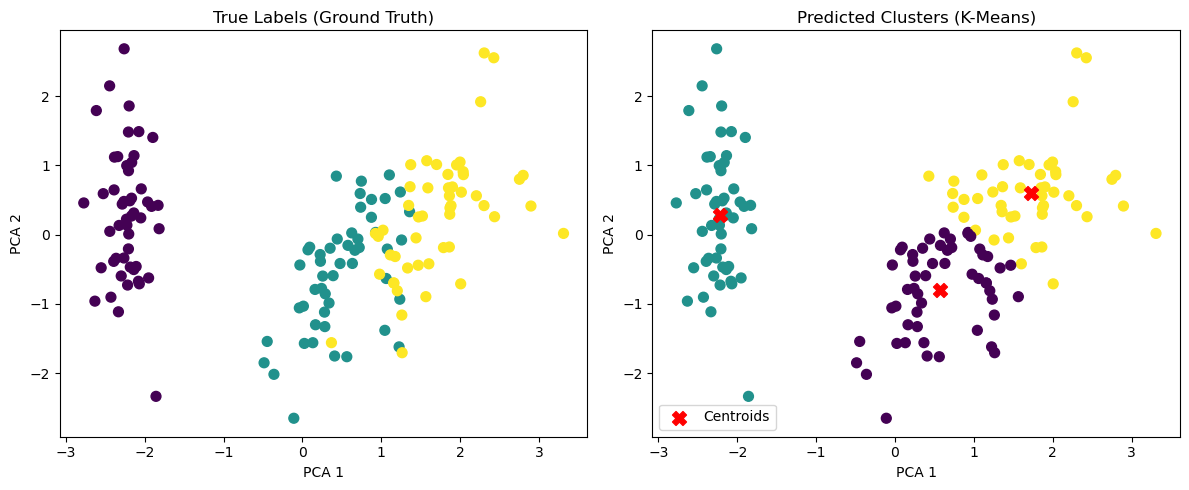

In [86]:
plt.figure(figsize=(12, 5))

# Left plot
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=50)
plt.title('True Labels (Ground Truth)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

# Right plot
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='viridis', s=50)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=100, label='Centroids')
plt.title('Predicted Clusters (K-Means)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()

plt.tight_layout()
plt.show()


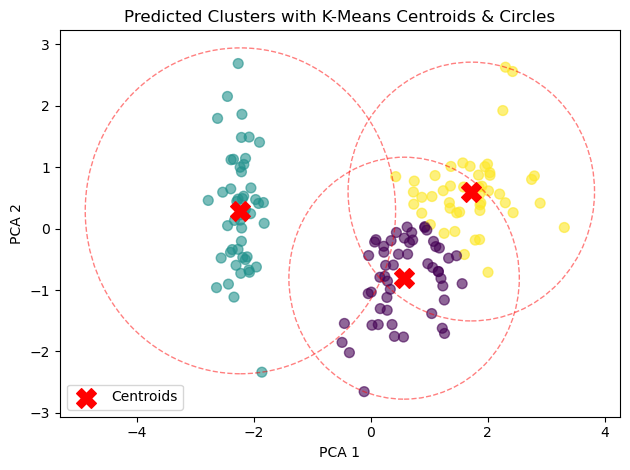

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='viridis', s=50, alpha=0.6)


plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, label='Centroids')


for i, center in enumerate(centers_pca):

    cluster_points = X_pca[y_pred == i]
    if len(cluster_points) > 0:
        radius = np.max(np.linalg.norm(cluster_points - center, axis=1))
        circle = plt.Circle(center, radius, color='red', fill=False, linestyle='--', alpha=0.5)
        plt.gca().add_patch(circle)

plt.title('Predicted Clusters with K-Means Centroids & Circles')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.tight_layout()
plt.show()

### PCA

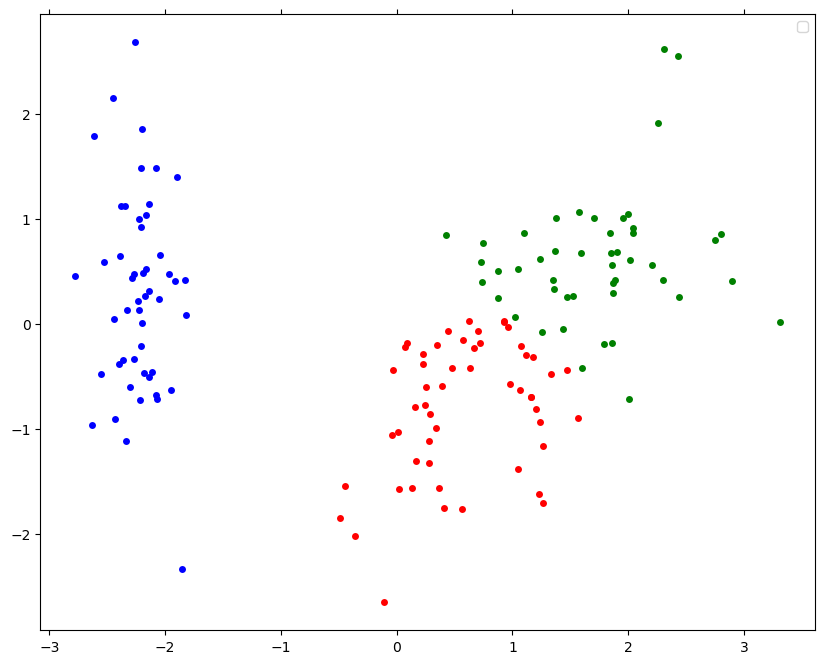

In [81]:
x, y = X_pca[:, 0], X_pca[:, 1]

colors = {0: 'red',
          1: 'blue',
          2: 'green'}

df = pd.DataFrame({'x': x, 'y':y, 'label':labels_kmean})
groups = df.groupby('label')

fig, ax = plt.subplots(figsize=(10, 8))

for name, group in groups:
    ax.plot(group.x, group.y, marker='o', linestyle='', ms=5,
            color=colors[name], mec='none')
            # color=colors[name],label=names[name], mec='none')
    ax.set_aspect('auto')
    ax.tick_params(axis='x',which='both',bottom='off',top='off',labelbottom='off')
    ax.tick_params(axis= 'y',which='both',left='off',top='off',labelleft='off')

ax.legend()
plt.show()